# Physics-Informed Conformal Prediction for Aromatic C–H Site-Selectivity
### Guaranteed-coverage prediction sets for electrophilic aromatic substitution, with quantum-chemical descriptors
**Author:** Ali A. Khairbek

This notebook builds, end to end, an uncertainty-aware model for the site-selectivity of
electrophilic aromatic substitution (EAS). It returns, for each molecule, a **set of candidate
sites with a finite-sample coverage guarantee** plus a principled out-of-domain flag.

**Three descriptor stages**
- **Stage 1** — fast atom-level descriptors from RDKit (Gasteiger charge shells, E-state,
  Crippen contributions, ring/topology).
- **Stage 2** — **GFN1-xTB** atomic-charge shells around each candidate site (computed with
  `tblite`): an atom-based charge-shell representation of electronic structure.
- **Stage 3** — **GFN1-xTB Fukui f⁻** (electrophilic-attack) indices, from the change in
  atomic charge on one-electron oxidation, encoding local susceptibility to electrophiles.

**Central experiment.** Conformal prediction guarantees coverage regardless of the model, so a
*better* descriptor set shows up as a *smaller* guaranteed prediction set at the same coverage.
The notebook tests whether adding GFN1-xTB electronic descriptors shrinks the guaranteed set
below the level reached with RDKit descriptors alone — the **Conformal Efficiency Curve**.

**Supporting analyses**
- A leave-one-out **ablation** of the electronic descriptors (which carry the signal).
- A chemical check that Fukui f⁻ ranks textbook EAS positions correctly.
- A robustness check that the coverage guarantee transfers across electrophile class.
- A Mondrian (class-conditional) coverage audit per substrate stratum.
- A conformal-credibility out-of-domain flag.

**Dataset.** Experimental EAS regioselectivity — 535 compounds with literature-reported
reaction centres (Ree, Göller & Jensen; `jensengroup/db-regioselectivity`, MIT license).

Run order: `Runtime → Run all`. The final cell packages every figure, the metrics, the pipeline
source and a short report into a downloadable `.zip`.


In [1]:
#@title Environment setup (dependencies, hardware, plotting)
import subprocess, sys
def _pip(pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
_pip(["rdkit", "lightgbm", "xgboost", "tblite"])

import os, json, shutil, textwrap, time, pickle, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, EState, rdMolDescriptors

def gpu_available():
    try:
        return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
    except Exception:
        return False
USE_GPU = gpu_available()

try:
    from tblite.interface import Calculator as _TBCalc
    TBLITE_OK = True
except Exception:
    TBLITE_OK = False
print("GPU runtime detected:", USE_GPU, "| GFN1-xTB (tblite) available:", TBLITE_OK)

SEED, ALPHA = 7, 0.10
rng = np.random.default_rng(SEED)
WONG = {"black":"#000000","orange":"#E69F00","skyblue":"#56B4E9","green":"#009E73",
        "yellow":"#F0E442","blue":"#0072B2","vermillion":"#D55E00","purple":"#CC79A7"}
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"savefig.bbox":"tight","font.size":11,
                     "axes.titlesize":12,"axes.titlepad":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.25,"figure.facecolor":"white"})
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)
def savefig(fig, name):
    fig.tight_layout(); path = os.path.join(FIGDIR, name); fig.savefig(path); plt.show(); plt.close(fig); return path


GPU runtime detected: True | GFN1-xTB (tblite) available: True


In [2]:
#@title Dataset (download + parse)
DATA = "db-regio/compounds_smiles.csv"
if not os.path.exists(DATA):
    subprocess.run(["git","clone","--depth","1",
                    "https://github.com/jensengroup/db-regioselectivity.git","db-regio"], check=True)
def load_records(path):
    recs = []
    for line in open(path):
        p = line.split()
        if len(p) < 3: continue
        centres = sorted({int(x) for x in p[2].split(",") if x.strip() != ""})
        if centres: recs.append((p[0], p[1], centres))
    return recs
records = load_records(DATA)
import re
def load_reagents(path):
    rmap = {}
    for line in open(path):
        line = line.rstrip("\n")
        if not line.strip(): continue
        p = line.split(None, 1)
        if len(p) < 2: continue
        cid, rest = p[0], p[1]; m = re.search(r"\(([^)]*)\)", rest)
        tag = m.group(1).replace("*", "").strip() if m else ""
        cls = ("bromination" if ("Br" in tag or "NBS" in tag)
               else "iodination" if ("NIS" in tag or "I2" in tag or tag == "I")
               else "chlorination" if ("NCS" in tag or "Cl" in tag) else "other")
        rmap[cid] = cls
    return rmap
REAGENTS = load_reagents("db-regio/compounds_yield.csv") if os.path.exists("db-regio/compounds_yield.csv") else {}
print("Compounds loaded:", len(records), "| reagent annotations:", len(REAGENTS))


Compounds loaded: 535 | reagent annotations: 535


In [3]:
#@title Stage-1 descriptors (RDKit, per aromatic C–H site)
def atom_features(mol, idx, estate, crippen):
    a = mol.GetAtomWithIdx(idx)
    q = float(a.GetProp("_GasteigerCharge"));  q = 0.0 if np.isnan(q) else q
    nbr = a.GetNeighbors(); nbr_q = [float(n.GetProp("_GasteigerCharge")) for n in nbr]
    sh = set()
    for n in nbr:
        sh.add(n.GetIdx())
        for n2 in n.GetNeighbors(): sh.add(n2.GetIdx())
    sh.discard(idx)
    shq = sum(float(mol.GetAtomWithIdx(j).GetProp("_GasteigerCharge")) for j in sh); shq = 0.0 if np.isnan(shq) else shq
    het = sum(1 for j in sh if mol.GetAtomWithIdx(j).GetSymbol() in ("N","O","S"))
    rs = [len(r) for r in mol.GetRingInfo().AtomRings() if idx in r]
    return {"q":q, "q_shell2_sum":shq, "q_nbr_min":min(nbr_q) if nbr_q else 0.0,
            "q_nbr_mean":float(np.mean(nbr_q)) if nbr_q else 0.0, "estate":float(estate[idx]),
            "n_het_shell2":het, "crippen_logp":float(crippen[idx][0]), "crippen_mr":float(crippen[idx][1]),
            "n_arom_nbr":sum(1 for n in nbr if n.GetIsAromatic()), "n_rings_atom":len(rs),
            "ring_min":min(rs) if rs else 0, "degree":a.GetDegree()}
RDKIT_FEATURES = ["q","q_shell2_sum","q_nbr_min","q_nbr_mean","estate","n_het_shell2",
                  "crippen_logp","crippen_mr","n_arom_nbr","n_rings_atom","ring_min","degree"]
print("Stage-1 descriptors:", len(RDKIT_FEATURES))


Stage-1 descriptors: 12


## Stage 2 — GFN1-xTB charge-shell descriptors
For each molecule a 3D geometry is generated (RDKit ETKDG + MMFF) and a single GFN1-xTB
single-point gives atomic charges; per candidate site we form charge-shell descriptors
(site charge, nearest-neighbour charge statistics, second-shell charge sum, and the site
charge relative to the molecular mean). Results are cached to disk. If GFN1-xTB is
unavailable for a molecule, the corresponding Stage-1 charge values are used so the table is
always complete.

In [4]:
#@title Stage-2/3 descriptors: GFN1-xTB charges + Fukui f- (cached)
RUN_XTB = True             #@param {type:"boolean"}
XTB_MAX_MOLECULES = 0      #@param {type:"integer"}   (0 = all molecules; set e.g. 120 for a quick subset)
ANG2BOHR = 1.0 / 0.52917721092
_XTB_CACHE = "xtb_features_cache.pkl"
try: _xcache = pickle.load(open(_XTB_CACHE, "rb"))
except Exception: _xcache = {}

def compute_xtb(smi):
    '''Heavy-atom GFN1-xTB charges (neutral) and Fukui f- = q(cation) - q(neutral),
    aligned to MolFromSmiles atom order. Returns (q, f); (None, None) on failure.'''
    if smi in _xcache: return _xcache[smi]
    qx = fx = None
    if RUN_XTB and TBLITE_OK:
        try:
            m = Chem.AddHs(Chem.MolFromSmiles(smi))
            if AllChem.EmbedMolecule(m, randomSeed=42) != 0:
                AllChem.EmbedMolecule(m, randomSeed=42, useRandomCoords=True)
            AllChem.MMFFOptimizeMolecule(m, maxIters=200)
            conf = m.GetConformer(); nums = np.array([a.GetAtomicNum() for a in m.GetAtoms()])
            pos = np.array([list(conf.GetAtomPosition(i)) for i in range(m.GetNumAtoms())]) * ANG2BOHR
            chg = sum(a.GetFormalCharge() for a in m.GetAtoms())
            nh  = Chem.MolFromSmiles(smi).GetNumHeavyAtoms()
            def _q(c, u):
                cc = _TBCalc("GFN1-xTB", nums, pos, charge=c, uhf=u); cc.set("verbosity", 0)
                return np.asarray(cc.singlepoint().get("charges"))
            qN = _q(chg, 0); qC = _q(chg + 1, 1)        # neutral and radical-cation single points
            qx = qN[:nh]; fx = (qC - qN)[:nh]           # f- (electrophilic) = q(cation) - q(neutral)
        except Exception:
            qx = fx = None
    _xcache[smi] = (qx, fx)
    return qx, fx

def _shell(mol, idx):
    nbr = mol.GetAtomWithIdx(idx).GetNeighbors(); sh = set()
    for n in nbr:
        sh.add(n.GetIdx())
        for n2 in n.GetNeighbors(): sh.add(n2.GetIdx())
    sh.discard(idx); return nbr, sh

def xtb_charge_features(mol, idx, qx, fb):
    if qx is None:
        return {"xtb_q":fb["q"], "xtb_q_nbr_min":fb["q_nbr_min"], "xtb_q_nbr_mean":fb["q_nbr_mean"],
                "xtb_q_shell2_sum":fb["q_shell2_sum"], "xtb_q_rel":0.0}
    nbr, sh = _shell(mol, idx); nbr_q = [qx[n.GetIdx()] for n in nbr if n.GetIdx() < len(qx)]
    shq = sum(qx[j] for j in sh if j < len(qx))
    return {"xtb_q":float(qx[idx]), "xtb_q_nbr_min":float(min(nbr_q)) if nbr_q else 0.0,
            "xtb_q_nbr_mean":float(np.mean(nbr_q)) if nbr_q else 0.0,
            "xtb_q_shell2_sum":float(shq), "xtb_q_rel":float(qx[idx]-np.mean(qx))}

def fukui_features(mol, idx, fx):
    if fx is None:
        return {"fukui_f":0.0, "fukui_nbr_mean":0.0, "fukui_rel":0.0}
    nbr, sh = _shell(mol, idx); nbr_f = [fx[n.GetIdx()] for n in nbr if n.GetIdx() < len(fx)]
    return {"fukui_f":float(fx[idx]), "fukui_nbr_mean":float(np.mean(nbr_f)) if nbr_f else 0.0,
            "fukui_rel":float(fx[idx]-np.mean(fx))}

XTB_CHARGE_FEATURES = ["xtb_q","xtb_q_nbr_min","xtb_q_nbr_mean","xtb_q_shell2_sum","xtb_q_rel"]
FUKUI_FEATURES = ["fukui_f","fukui_nbr_mean","fukui_rel"]
print("Stage-2 (xTB charge) descriptors:", len(XTB_CHARGE_FEATURES),
      "| Stage-3 (Fukui) descriptors:", len(FUKUI_FEATURES))


Stage-2 (xTB charge) descriptors: 5 | Stage-3 (Fukui) descriptors: 3


In [5]:
#@title Build the descriptor table (Stage 1 + 2 + 3)
def build_table(records):
    rows = []; n_ok = 0; t0 = time.time()
    sel = records if XTB_MAX_MOLECULES in (0, None) else records[:XTB_MAX_MOLECULES]
    for mol_id, (cid, smi, centres) in enumerate(sel):
        mol = Chem.MolFromSmiles(smi); AllChem.ComputeGasteigerCharges(mol)
        estate = EState.EStateIndices(mol); crippen = rdMolDescriptors._CalcCrippenContribs(mol)
        qx, fx = compute_xtb(smi); n_ok += int(qx is not None)
        cands = [a.GetIdx() for a in mol.GetAtoms()
                 if a.GetIsAromatic() and a.GetSymbol() == "C" and a.GetTotalNumHs() >= 1]
        centre_set = tuple(c for c in centres if c in cands)
        if not centre_set: continue
        for s in cands:
            f = atom_features(mol, s, estate, crippen)
            f.update(xtb_charge_features(mol, s, qx, f)); f.update(fukui_features(mol, s, fx))
            f.update(mol_id=mol_id, cid=cid, site=s, is_true=int(s in centre_set),
                     n_sites=len(cands), centres=centre_set)
            rows.append(f)
    pickle.dump(_xcache, open(_XTB_CACHE, "wb"))
    print(f"GFN1-xTB succeeded for {n_ok}/{len(sel)} molecules  ({time.time()-t0:.0f}s)")
    return pd.DataFrame(rows)

df = build_table(records)
FEATURES_S1 = RDKIT_FEATURES[:]                                       # RDKit
FEATURES_S2 = RDKIT_FEATURES + XTB_CHARGE_FEATURES                    # + xTB charges (main text)
FEATURES_S3 = RDKIT_FEATURES + XTB_CHARGE_FEATURES + FUKUI_FEATURES   # + Fukui f-
FEATURE_ORDER = FEATURES_S3                                           # for the efficiency curve
ELEC_FEATURES = XTB_CHARGE_FEATURES + FUKUI_FEATURES                  # for the ablation
HEADLINE_FEATURES = FEATURES_S2                                       # main-text conformal diagnostics
N_RD, N_CHG, N_FUK = len(RDKIT_FEATURES), len(XTB_CHARGE_FEATURES), len(FUKUI_FEATURES)
print(f"Molecules: {df.mol_id.nunique()} | candidate sites: {len(df)} | observed centres: {int(df.is_true.sum())}")
print(f"Descriptors -> Stage-1: {len(FEATURES_S1)} | Stage-2: {len(FEATURES_S2)} | Stage-3: {len(FEATURES_S3)}")
df.head()


[10:53:19] UFFTYPER: Unrecognized atom type: S_6+6 (7)
[10:53:52] UFFTYPER: Unrecognized atom type: S_6+6 (7)
[10:53:53] UFFTYPER: Unrecognized atom type: S_6+6 (6)
[10:53:57] UFFTYPER: Unrecognized atom type: Se2+2 (6)
[10:53:57] UFFTYPER: Unrecognized atom type: Se2+2 (6)


GFN1-xTB succeeded for 534/535 molecules  (194s)
Molecules: 535 | candidate sites: 2683 | observed centres: 604
Descriptors -> Stage-1: 12 | Stage-2: 17 | Stage-3: 20


,q,q_shell2_sum,q_nbr_min,q_nbr_mean,estate,n_het_shell2,crippen_logp,crippen_mr,n_arom_nbr,n_rings_atom,...,xtb_q_rel,fukui_f,fukui_nbr_mean,fukui_rel,mol_id,cid,site,is_true,n_sites,centres
0,0.048663,-0.472833,-0.184287,-0.104310,1.694444,2,0.1581,3.35,2,1,...,0.158146,0.086539,0.166563,-0.036351,0,comp1,1,0,3,"(2,)"
1,-0.024334,-0.399836,0.021544,0.035103,1.833333,2,0.1581,3.35,2,1,...,-0.038484,0.128413,0.103394,0.005523,0,comp1,2,1,3,"(2,)"
2,0.021544,-0.445713,-0.285756,-0.155045,1.763889,2,0.1581,3.35,2,1,...,0.123722,0.120249,0.101475,-0.002641,0,comp1,3,0,3,"(2,)"
3,0.049477,-0.369498,-0.173840,-0.098654,1.690833,2,0.1581,3.35,2,1,...,0.128802,0.052296,0.084574,-0.005352,1,comp2,1,0,6,"(2,)"
4,-0.023467,-0.296553,0.034007,0.041742,1.829722,2,0.1581,3.35,2,1,...,-0.069607,0.073942,0.054369,0.016294,1,comp2,2,1,6,"(2,)"


In [6]:
#@title Base classifier (GPU-aware) and conformal primitives
from sklearn.ensemble import HistGradientBoostingClassifier
def make_model(use_gpu):
    try:
        from xgboost import XGBClassifier
        return ("xgboost", XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", verbosity=0,
                tree_method="hist", device=("cuda" if use_gpu else "cpu")))
    except Exception: pass
    try:
        from lightgbm import LGBMClassifier
        return ("lightgbm", LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9, random_state=SEED, verbosity=-1))
    except Exception:
        return ("sklearn", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05,
                max_iter=400, random_state=SEED))

def fit_predict(features, train_set=None):
    '''Fit the base model and attach a per-molecule site distribution pi.'''
    train_set = train_m if train_set is None else train_set
    name, model = make_model(USE_GPU); tr = df[df.mol_id.isin(train_set)]
    try: model.fit(tr[features], tr["is_true"])
    except Exception:
        name, model = make_model(False); model.fit(tr[features], tr["is_true"])
    d = df.copy(); d["p"] = model.predict_proba(d[features])[:, 1]; d["pc"] = d["p"].clip(1e-6)
    d["pi"] = d["pc"] / d.groupby("mol_id")["pc"].transform("sum")
    return d, name

def aps_score(pi, target, lam=0.0, k_reg=1):
    pi = np.asarray(pi); order = np.argsort(-pi); rank = int(np.where(order == target)[0][0])
    return pi[order][:rank+1].sum() + lam * max(0, (rank+1) - k_reg)
def predict_set(pi, qhat, lam=0.0, k_reg=1):
    pi = np.asarray(pi); order = np.argsort(-pi); mask = np.zeros(len(pi), bool); b = 0.0
    for r, idx in enumerate(order):
        if b + pi[idx] + lam*max(0,(r+1)-k_reg) <= qhat: mask[idx] = True
        b += pi[idx]
    return mask
def conf_quantile(scores, alpha):
    s = np.sort(np.asarray(scores)); n = len(s); return s[min(int(np.ceil((n+1)*(1-alpha))), n)-1]

MEDIAN_SITES = int(df.groupby("mol_id").n_sites.first().median())
def stratum_of(n): return "few" if n <= MEDIAN_SITES else "many"
def calibration_scores(d, lam=0.0, cal_set=None):
    cal_set = cal_m if cal_set is None else cal_set; out = []
    for mid, g in d[d.mol_id.isin(cal_set)].groupby("mol_id"):
        pi = g["pi"].values; sites = list(g["site"].values); centres = g["centres"].iloc[0]
        out.append((mid, stratum_of(g["n_sites"].iloc[0]),
                    min(aps_score(pi, sites.index(c), lam) for c in centres if c in sites)))
    return pd.DataFrame(out, columns=["mol_id","stratum","score"])
def evaluate(d, qfn, lam=0.0, cal_scores=None, test_set=None):
    test_set = test_m if test_set is None else test_set; out = []
    for mid, g in d[d.mol_id.isin(test_set)].groupby("mol_id"):
        pi = g["pi"].values; sites = list(g["site"].values); centres = g["centres"].iloc[0]
        st = stratum_of(g["n_sites"].iloc[0]); mask = predict_set(pi, qfn(st), lam)
        covered = any(mask[sites.index(c)] for c in centres if c in sites)
        top1 = sites[int(np.argmax(pi))] in centres; cred = np.nan
        if cal_scores is not None:
            s_top = aps_score(pi, int(np.argmax(pi)))
            cred = (1 + np.sum(np.asarray(cal_scores) >= s_top)) / (len(cal_scores) + 1)
        out.append((st, covered, int(mask.sum()), top1, cred))
    return pd.DataFrame(out, columns=["stratum","covered","setsize","top1","credibility"])
print("Base classifier:", make_model(USE_GPU)[0])


Base classifier: xgboost


In [7]:
#@title Split, primary fit, repeated-split statistics, Stage-1 vs Stage-2
K_SPLITS = 15
ALPHAS = np.linspace(0.04, 0.30, 10)
def make_split(seed):
    r = np.random.default_rng(seed); m = df["mol_id"].unique().copy(); r.shuffle(m); k = len(m)
    return set(m[:int(.50*k)]), set(m[int(.50*k):int(.75*k)]), set(m[int(.75*k):])

train_m, cal_m, test_m = make_split(SEED)
print(f"Representative split -> train {len(train_m)} | calibrate {len(cal_m)} | test {len(test_m)}")
d_fit, model_name = fit_predict(HEADLINE_FEATURES)
cal = calibration_scores(d_fit)
q_marg = conf_quantile(cal["score"].values, ALPHA)
q_mond = {s: conf_quantile(cal.loc[cal.stratum == s, "score"].values, ALPHA) for s in cal.stratum.unique()}
res_marg = evaluate(d_fit, lambda s: q_marg, cal_scores=cal["score"].values)
res_mond = evaluate(d_fit, lambda s: q_mond[s], cal_scores=cal["score"].values)

rows = []; sweep_marg = np.zeros(len(ALPHAS)); sweep_mond = np.zeros(len(ALPHAS)); top1 = []
for sd in range(K_SPLITS):
    tr, ca, te = make_split(2000 + sd); d, _ = fit_predict(HEADLINE_FEATURES, train_set=tr)
    c = calibration_scores(d, cal_set=ca); qm = conf_quantile(c["score"].values, ALPHA)
    qd = {s: conf_quantile(c.loc[c.stratum == s, "score"].values, ALPHA) for s in c.stratum.unique()}
    rm = evaluate(d, lambda s: qm, test_set=te); rd = evaluate(d, lambda s: qd[s], test_set=te)
    top1.append(rd.top1.mean())
    for meth, res in [("marginal", rm), ("mondrian", rd)]:
        for strat in ["overall", "few", "many"]:
            sub = res if strat == "overall" else res[res.stratum == strat]
            rows.append((strat, meth, sub.covered.mean(), sub.setsize.mean()))
    for i, a in enumerate(ALPHAS):
        qma = conf_quantile(c["score"].values, a)
        qda = {s: conf_quantile(c.loc[c.stratum == s, "score"].values, a) for s in c.stratum.unique()}
        sweep_marg[i] += evaluate(d, lambda s: qma, test_set=te).covered.mean()
        sweep_mond[i] += evaluate(d, lambda s: qda[s], test_set=te).covered.mean()
sweep_marg /= K_SPLITS; sweep_mond /= K_SPLITS
agg = pd.DataFrame(rows, columns=["stratum","method","cov","set"])
METRICS = (agg.groupby(["stratum","method"]).agg(coverage=("cov","mean"),
           coverage_sd=("cov","std"), set_size=("set","mean")).round(3))
TOP1 = float(np.mean(top1))

def stage_stats(features, K=K_SPLITS):
    cov, ss, t1 = [], [], []
    for sd in range(K):
        tr, ca, te = make_split(5000 + sd); d, _ = fit_predict(features, train_set=tr)
        c = calibration_scores(d, cal_set=ca); q = conf_quantile(c["score"].values, ALPHA)
        r = evaluate(d, lambda s: q, test_set=te)
        cov.append(r.covered.mean()); ss.append(r.setsize.mean()); t1.append(r.top1.mean())
    return dict(cov=np.mean(cov), set_mean=np.mean(ss), set_sd=np.std(ss), top1=np.mean(t1))
S1 = stage_stats(FEATURES_S1); S2 = stage_stats(FEATURES_S2); S3 = stage_stats(FEATURES_S3)
print(f"\nTarget coverage = {1-ALPHA:.2f} | classifier = {model_name} | splits = {K_SPLITS}")
print(f"Stage-1 (RDKit)              : coverage {S1['cov']:.3f} | set {S1['set_mean']:.2f}±{S1['set_sd']:.2f} | top-1 {S1['top1']:.3f}")
print(f"Stage-2 (RDKit + xTB charge) : coverage {S2['cov']:.3f} | set {S2['set_mean']:.2f}±{S2['set_sd']:.2f} | top-1 {S2['top1']:.3f}")
print(f"Stage-3 (+ Fukui f-)         : coverage {S3['cov']:.3f} | set {S3['set_mean']:.2f}±{S3['set_sd']:.2f} | top-1 {S3['top1']:.3f}")
METRICS


Representative split -> train 267 | calibrate 134 | test 134

Target coverage = 0.90 | classifier = xgboost | splits = 15
Stage-1 (RDKit)              : coverage 0.886 | set 2.80±0.35 | top-1 0.749
Stage-2 (RDKit + xTB charge) : coverage 0.910 | set 2.74±0.30 | top-1 0.818
Stage-3 (+ Fukui f-)         : coverage 0.904 | set 2.62±0.34 | top-1 0.862


coverage  coverage_sd  set_size
stratum method                                   
few     marginal     0.846        0.077     1.640
        mondrian     0.915        0.051     1.956
many    marginal     0.991        0.019     4.165
        mondrian     0.924        0.064     2.526
overall marginal     0.910        0.048     2.740
        mondrian     0.920        0.035     2.207

## Figure 1 — Validity across the confidence level

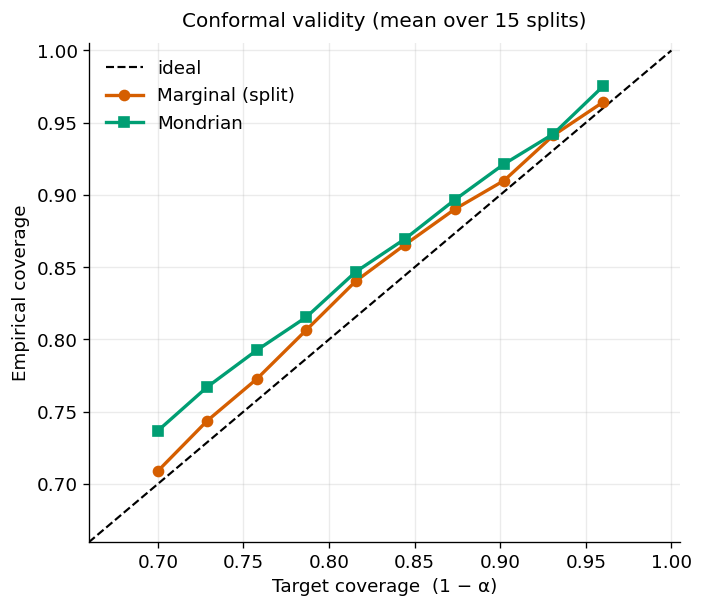

In [8]:
#@title Figure 1: empirical coverage vs target (mean over splits)
fig, ax = plt.subplots(figsize=(6.0, 5.2))
ax.plot([0.6,1.0],[0.6,1.0], ls="--", color=WONG["black"], lw=1.3, label="ideal")
ax.plot(1-ALPHAS, sweep_marg, "o-", color=WONG["vermillion"], lw=2, label="Marginal (split)")
ax.plot(1-ALPHAS, sweep_mond, "s-", color=WONG["green"], lw=2, label="Mondrian")
ax.set_xlabel("Target coverage  (1 − α)"); ax.set_ylabel("Empirical coverage")
ax.set_title(f"Conformal validity (mean over {K_SPLITS} splits)")
ax.set_xlim(0.66,1.005); ax.set_ylim(0.66,1.005); ax.legend(frameon=False, loc="upper left")
F1 = savefig(fig, "fig1_validity.png")


## Figure 2 — Conditional coverage by substrate stratum

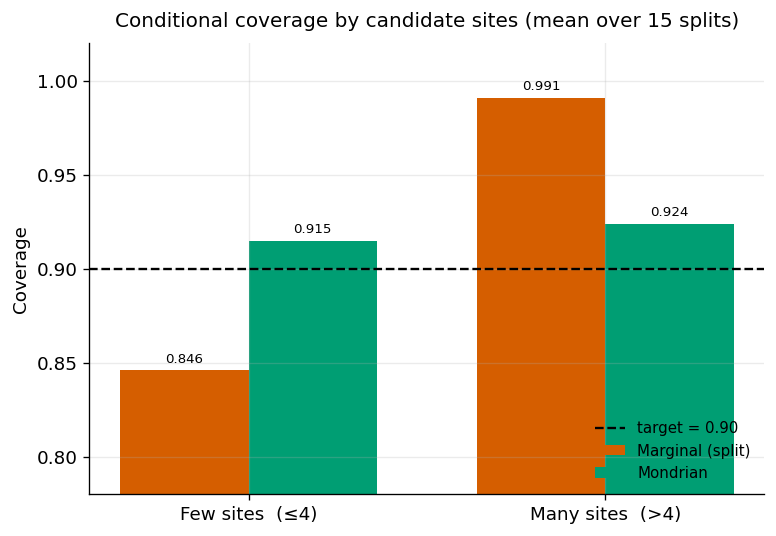

In [9]:
#@title Figure 2: coverage within each candidate-site stratum
strata = ["few","many"]
cmarg = [METRICS.loc[(s,"marginal"),"coverage"] for s in strata]
cmond = [METRICS.loc[(s,"mondrian"),"coverage"] for s in strata]
x = np.arange(2); w = 0.36
fig, ax = plt.subplots(figsize=(6.6, 4.6))
b1 = ax.bar(x-w/2, cmarg, w, color=WONG["vermillion"], label="Marginal (split)")
b2 = ax.bar(x+w/2, cmond, w, color=WONG["green"], label="Mondrian")
ax.axhline(1-ALPHA, ls="--", color=WONG["black"], lw=1.4, label=f"target = {1-ALPHA:.2f}")
ax.set_xticks(x); ax.set_xticklabels([f"Few sites  (≤{MEDIAN_SITES})", f"Many sites  (>{MEDIAN_SITES})"])
ax.set_ylabel("Coverage"); ax.set_ylim(0.78, 1.02)
ax.set_title(f"Conditional coverage by candidate sites (mean over {K_SPLITS} splits)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8); ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
F2 = savefig(fig, "fig2_conditional_coverage.png")


## Figure 3 — Prediction-set size distribution

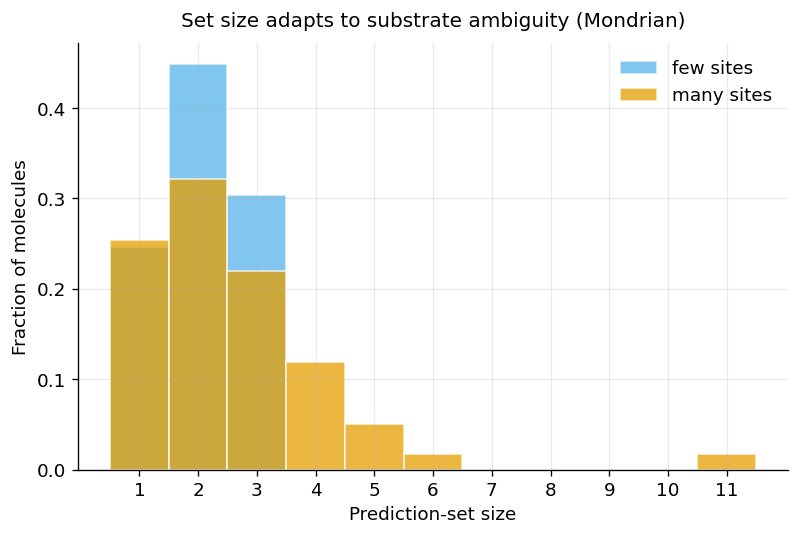

In [10]:
#@title Figure 3: set-size distribution by stratum (Stage 2)
fig, ax = plt.subplots(figsize=(6.8, 4.6))
hi = int(res_mond.setsize.max()); bins = np.arange(0.5, hi+1.5, 1)
for s, col in [("few", WONG["skyblue"]), ("many", WONG["orange"])]:
    ax.hist(res_mond[res_mond.stratum == s].setsize, bins=bins, density=True, alpha=0.75,
            color=col, edgecolor="white", label=f"{s} sites")
ax.set_xlabel("Prediction-set size"); ax.set_ylabel("Fraction of molecules"); ax.set_xticks(range(1, hi+1))
ax.set_title("Set size adapts to substrate ambiguity (Mondrian)")
ax.legend(frameon=False, loc="upper right")
F3 = savefig(fig, "fig3_setsize.png")


## Figure 4 — Conformal Efficiency Curve: RDKit → +xTB charges → +Fukui  *(central experiment)*
Mean prediction-set size at a fixed coverage guarantee as descriptors are added cumulatively:
the RDKit block, then the GFN1-xTB charge block (green), then the Fukui f⁻ block (purple). The
dotted line marks the plateau reached with RDKit descriptors alone; electronic blocks that push
the curve **below** it give a genuinely smaller guaranteed set at the same coverage. Averaged
over splits with a ±SD band.

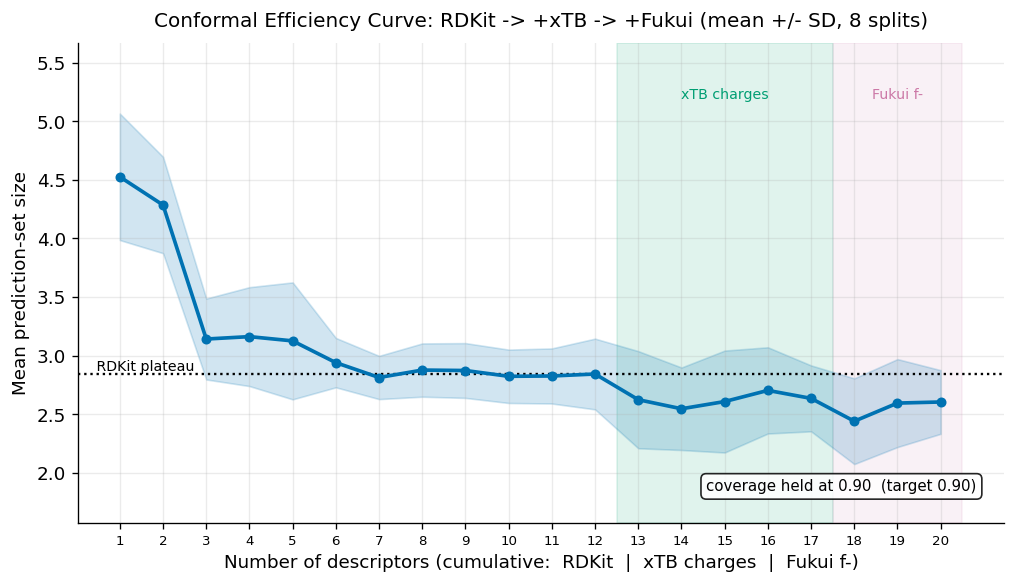

 n_descriptors  mean_set_size  sd_set_size  coverage
             1          4.525        0.540     0.953
             2          4.285        0.411     0.932
             3          3.141        0.345     0.904
             4          3.161        0.422     0.894
             5          3.125        0.499     0.898
             6          2.939        0.211     0.896
             7          2.813        0.185     0.888
             8          2.876        0.227     0.898
             9          2.872        0.234     0.888
            10          2.823        0.228     0.895
            11          2.826        0.235     0.896
            12          2.842        0.302     0.892
            13          2.623        0.415     0.899
            14          2.546        0.352     0.887
            15          2.607        0.435     0.904
            16          2.702        0.368     0.915
            17          2.634        0.281     0.912
            18          2.439        0.366    

In [11]:
#@title Figure 4: efficiency curve (RDKit block, then xTB block)
K_EFF = 8
curve = np.zeros((K_EFF, len(FEATURE_ORDER))); covs = np.zeros((K_EFF, len(FEATURE_ORDER)))
for sd in range(K_EFF):
    tr, ca, te = make_split(3000 + sd)
    for ki in range(1, len(FEATURE_ORDER)+1):
        feats = FEATURE_ORDER[:ki]; dk, _ = fit_predict(feats, train_set=tr)
        calk = calibration_scores(dk, cal_set=ca); qk = conf_quantile(calk["score"].values, ALPHA)
        rk = evaluate(dk, lambda s: qk, test_set=te)
        curve[sd, ki-1] = rk.setsize.mean(); covs[sd, ki-1] = rk.covered.mean()
ks = np.arange(1, len(FEATURE_ORDER)+1); mean_sz = curve.mean(0); sd_sz = curve.std(0); mean_cov = float(covs.mean())
chg_end = N_RD + N_CHG; plateau = mean_sz[N_RD-1]
fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.axvspan(N_RD+0.5, chg_end+0.5, color=WONG["green"], alpha=0.12)
ax.axvspan(chg_end+0.5, len(FEATURE_ORDER)+0.5, color=WONG["purple"], alpha=0.10)
ax.axhline(plateau, ls=":", color=WONG["black"], lw=1.4)
ax.fill_between(ks, mean_sz-sd_sz, mean_sz+sd_sz, color=WONG["blue"], alpha=0.18)
ax.plot(ks, mean_sz, "o-", color=WONG["blue"], lw=2.2, markersize=5)
ax.set_xlabel("Number of descriptors (cumulative:  RDKit  |  xTB charges  |  Fukui f-)")
ax.set_ylabel("Mean prediction-set size"); ax.set_xticks(ks); ax.tick_params(axis="x", labelsize=8)
ax.set_ylim((mean_sz-sd_sz).min()-0.5, (mean_sz+sd_sz).max()+0.6)
ax.set_title(f"Conformal Efficiency Curve: RDKit -> +xTB -> +Fukui (mean +/- SD, {K_EFF} splits)")
_ytop = (mean_sz+sd_sz).max()
ax.text(N_RD + N_CHG/2.0 + 0.5, _ytop+0.10, "xTB charges", ha="center", va="bottom", fontsize=8.5, color=WONG["green"])
ax.text(chg_end + N_FUK/2.0 + 0.5, _ytop+0.10, "Fukui f-", ha="center", va="bottom", fontsize=8.5, color=WONG["purple"])
ax.text(0.015, plateau, " RDKit plateau", va="bottom", ha="left", fontsize=8.5, transform=ax.get_yaxis_transform())
ax.text(0.97, 0.06, f"coverage held at {mean_cov:.2f}  (target {1-ALPHA:.2f})", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=WONG["black"], alpha=0.85))
F4 = savefig(fig, "fig4_efficiency_curve.png")
eff = pd.DataFrame({"n_descriptors": ks, "mean_set_size": np.round(mean_sz,3),
                    "sd_set_size": np.round(sd_sz,3), "coverage": np.round(covs.mean(0),3)})
sizes = list(mean_sz); print(eff.to_string(index=False))


## Figure 4b — Stage 1 vs Stage 2: does GFN1-xTB shrink the guaranteed set?

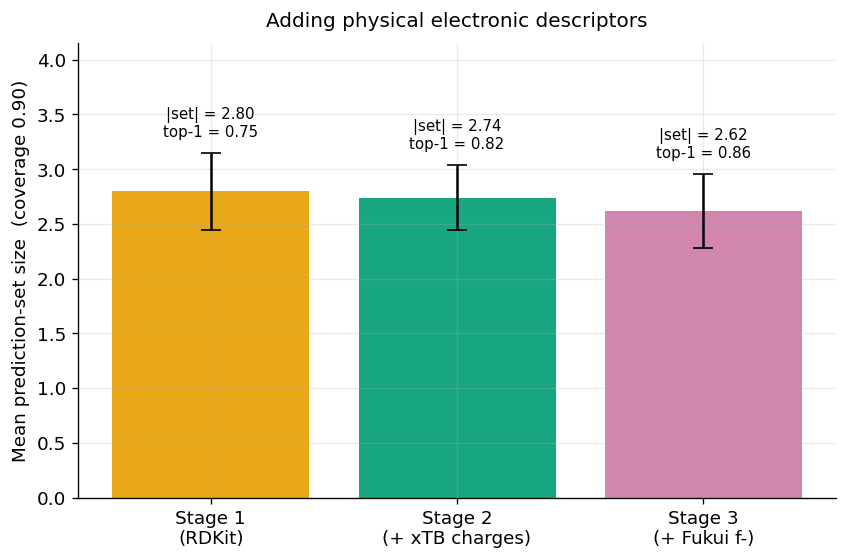

In [12]:
#@title Figure 4b: Stage-1 vs Stage-2 set size and accuracy
labels = ["Stage 1\n(RDKit)", "Stage 2\n(+ xTB charges)", "Stage 3\n(+ Fukui f-)"]
vals = [S1["set_mean"], S2["set_mean"], S3["set_mean"]]
errs = [S1["set_sd"], S2["set_sd"], S3["set_sd"]]; t1s = [S1["top1"], S2["top1"], S3["top1"]]
fig, ax = plt.subplots(figsize=(7.2, 4.8))
bars = ax.bar(labels, vals, yerr=errs, capsize=6, color=[WONG["orange"], WONG["green"], WONG["purple"]], alpha=0.9)
ax.set_ylabel(f"Mean prediction-set size  (coverage {1-ALPHA:.2f})")
ax.set_title("Adding physical electronic descriptors")
for b, v, e, t1 in zip(bars, vals, errs, t1s):
    ax.text(b.get_x()+b.get_width()/2, v+e+0.12, f"|set| = {v:.2f}\ntop-1 = {t1:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(v+e for v, e in zip(vals, errs)) + 1.0)
F4b = savefig(fig, "fig4b_stage_comparison.png")


## Figure 6 — Contribution of each electronic descriptor
Starting from the RDKit baseline, each electronic descriptor is added on its own; the gain in
top-1 accuracy measures how much site-selectivity information that quantity carries. This
attributes the improvement to specific physical descriptors rather than selecting features on
test performance.

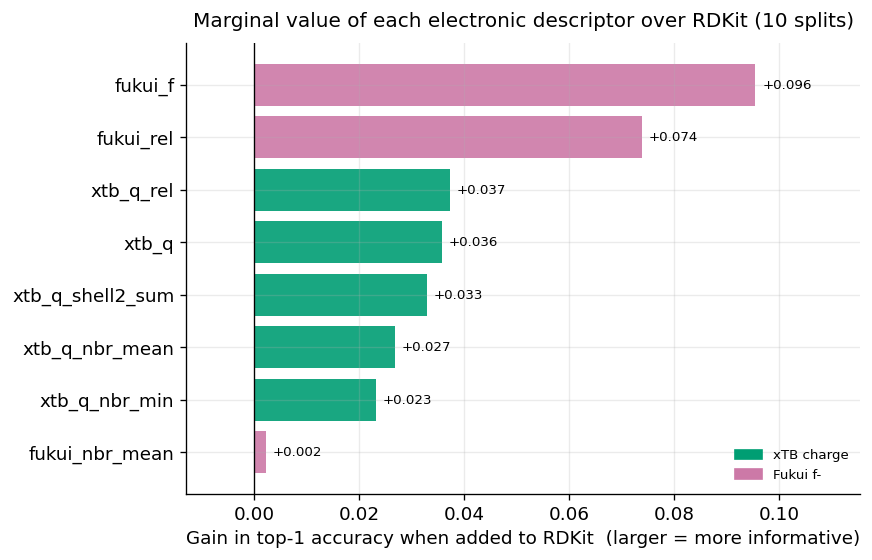

      descriptor  d_top1  d_setsize
  fukui_nbr_mean  0.0022    -0.2545
   xtb_q_nbr_min  0.0231    -0.0604
  xtb_q_nbr_mean  0.0269     0.0448
xtb_q_shell2_sum  0.0328     0.1724
           xtb_q  0.0358     0.3701
       xtb_q_rel  0.0373     0.1418
       fukui_rel  0.0739     0.2925
         fukui_f  0.0955     0.4619


In [13]:
#@title Figure 6: leave-one-out importance of electronic descriptors
K_ABL = 10
base = stage_stats(FEATURES_S1, K=K_ABL)            # RDKit-only baseline
imp = []
for feat in ELEC_FEATURES:
    r = stage_stats(FEATURES_S1 + [feat], K=K_ABL)   # RDKit + this one electronic descriptor
    imp.append((feat, r["top1"] - base["top1"], base["set_mean"] - r["set_mean"]))
abl = pd.DataFrame(imp, columns=["descriptor", "d_top1", "d_setsize"]).sort_values("d_top1")
fig, ax = plt.subplots(figsize=(7.4, 4.8))
cols = [WONG["green"] if d.startswith("xtb") else WONG["purple"] for d in abl["descriptor"]]
ax.barh(abl["descriptor"], abl["d_top1"], color=cols, alpha=0.9)
ax.axvline(0, color=WONG["black"], lw=0.8)
ax.set_xlabel("Gain in top-1 accuracy when added to RDKit  (larger = more informative)")
ax.set_title(f"Marginal value of each electronic descriptor over RDKit ({K_ABL} splits)")
ax.set_xlim(min(abl["d_top1"].min(), 0) - 0.013, abl["d_top1"].max() + 0.020)
for y, v in enumerate(abl["d_top1"]):
    ax.text(v + (0.0013 if v >= 0 else -0.0013), y, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8)
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=WONG["green"]), plt.Rectangle((0,0),1,1,color=WONG["purple"])],
          labels=["xTB charge", "Fukui f-"], frameon=False, fontsize=8, loc="lower right")
F6 = savefig(fig, "fig6_ablation.png")
print(abl.round(4).to_string(index=False))


## Figure 7 — Chemical check: Fukui f⁻ ranks textbook EAS positions
For archetypal substrates the mean GFN1-xTB Fukui f⁻ at the position favoured by classical EAS
rules is compared with the other aromatic C–H positions. Higher f⁻ at the favoured site shows
the descriptor encodes genuine electrophilic-attack selectivity.

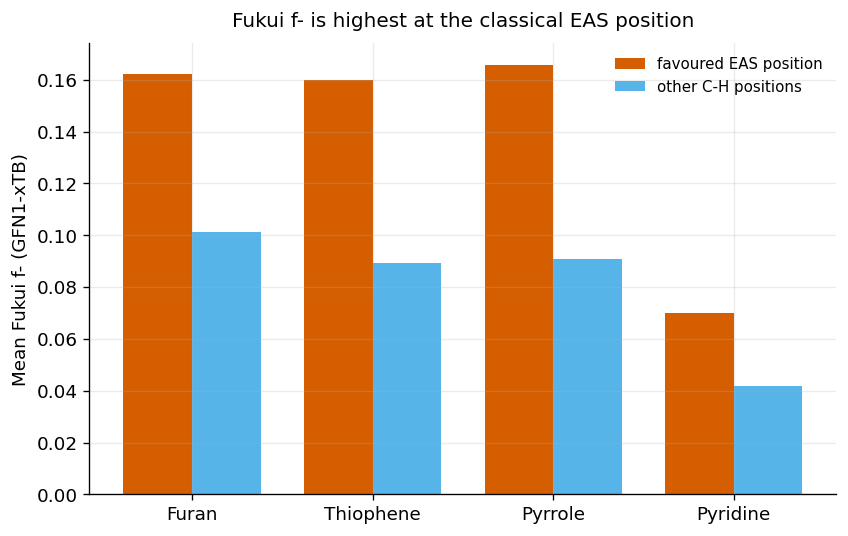

substrate  f_favoured  f_other
    Furan       0.162    0.101
Thiophene       0.160    0.089
  Pyrrole       0.166    0.091
 Pyridine       0.070    0.042


In [14]:
#@title Figure 7: Fukui f- vs classical EAS preference
ARCHE = [("Furan","c1ccoc1","O",1), ("Thiophene","c1ccsc1","S",1),
         ("Pyrrole","c1cc[nH]c1","N",1), ("Pyridine","c1ccncc1","N",2)]
names, fav_v, oth_v = [], [], []
for nm, smi, het, L in ARCHE:
    _q, fvals = compute_xtb(smi)
    mol = Chem.MolFromSmiles(smi); D = Chem.GetDistanceMatrix(mol)
    hets = [a.GetIdx() for a in mol.GetAtoms() if a.GetSymbol() == het]
    ch = [a.GetIdx() for a in mol.GetAtoms() if a.GetIsAromatic() and a.GetSymbol() == "C" and a.GetTotalNumHs() >= 1]
    fav = [i for i in ch if min(D[i][h] for h in hets) == L]; oth = [i for i in ch if i not in fav]
    names.append(nm); fav_v.append(float(np.mean([fvals[i] for i in fav])))
    oth_v.append(float(np.mean([fvals[i] for i in oth])) if oth else np.nan)
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.bar(x - w/2, fav_v, w, color=WONG["vermillion"], label="favoured EAS position")
ax.bar(x + w/2, oth_v, w, color=WONG["skyblue"], label="other C-H positions")
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("Mean Fukui f- (GFN1-xTB)")
ax.set_title("Fukui f- is highest at the classical EAS position")
ax.legend(frameon=False, fontsize=9)
F7 = savefig(fig, "fig7_fukui_validation.png")
fuk_val = pd.DataFrame({"substrate": names, "f_favoured": np.round(fav_v,3), "f_other": np.round(oth_v,3)})
print(fuk_val.to_string(index=False))


## Figure 5 — Conformal credibility (out-of-domain flag)
The conformal credibility of a molecule is the calibration p-value of its top-ranked site;
low-credibility molecules are poorly explained by the calibration set and are flagged for
experimental confirmation — a distribution-free applicability domain.

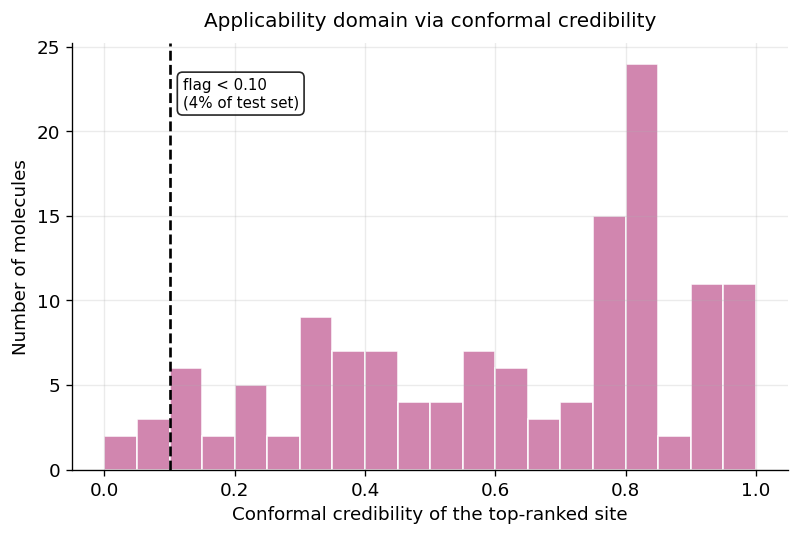

In [15]:
#@title Figure 5: credibility distribution + flagging threshold
THRESH = 0.10
cred = res_mond["credibility"].dropna().values; flagged = float(np.mean(cred < THRESH))
fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.hist(cred, bins=np.linspace(0,1,21), color=WONG["purple"], edgecolor="white", alpha=0.9)
ax.axvline(THRESH, ls="--", color=WONG["black"], lw=1.6)
ax.set_xlabel("Conformal credibility of the top-ranked site"); ax.set_ylabel("Number of molecules")
ax.set_title("Applicability domain via conformal credibility")
ax.text(THRESH+0.02, ax.get_ylim()[1]*0.92, f"flag < {THRESH:.2f}\n({flagged:.0%} of test set)", fontsize=9,
        va="top", bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=WONG["black"], alpha=0.85))
F5 = savefig(fig, "fig5_credibility_ood.png")


## Figure 8 — Robustness of the guarantee across electrophile class
Using out-of-fold predictions, coverage and set size are broken down by halogenation type
(bromination, iodination, chlorination). A distribution-free guarantee should transfer across
electrophiles, since aromatic site-selectivity is governed by arene electronics rather than the
identity of the halogen. Homogeneous coverage near the target supports reagent-agnostic
applicability.

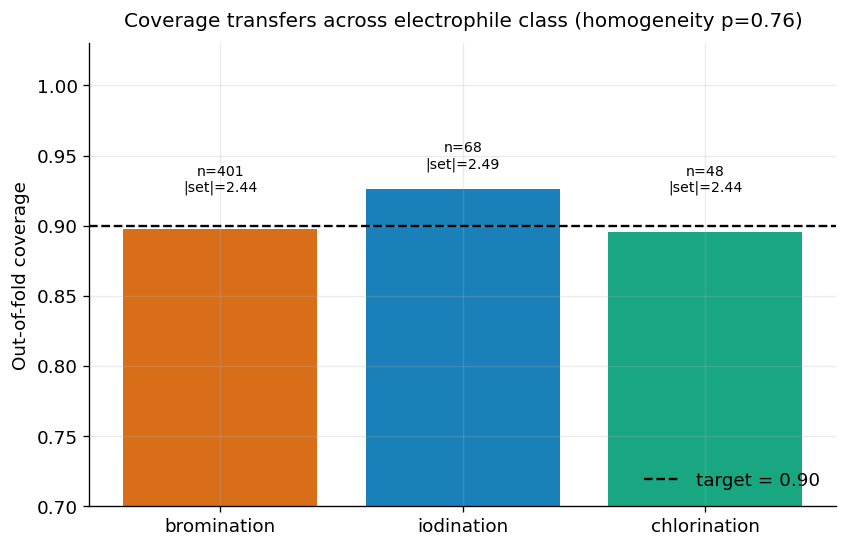

       class   n  coverage  set_mean
 bromination 401     0.898     2.444
  iodination  68     0.926     2.485
chlorination  48     0.896     2.438
chi-square homogeneity: chi2=0.56, p=0.757


In [16]:
#@title Figure 8: coverage by halogenation class (out-of-fold)
from scipy.stats import chi2_contingency
_mols = np.array(sorted(df.mol_id.unique())); _perm = np.random.default_rng(0).permutation(_mols)
_folds = np.array_split(_perm, 5); oof = []
for k in range(5):
    te = set(_folds[k].tolist()); rest = [int(m) for m in _perm if m not in te]
    cut = int(0.75*len(rest)); tr = set(rest[:cut]); ca = set(rest[cut:])
    d, _ = fit_predict(HEADLINE_FEATURES, train_set=tr)
    cs = calibration_scores(d, cal_set=ca); q = conf_quantile(cs["score"].values, ALPHA)
    for mid in te:
        g = d[d.mol_id == mid]; pi = g["pi"].values; sites = list(g["site"].values); cen = g["centres"].iloc[0]
        mask = predict_set(pi, q); cov = any(mask[sites.index(c)] for c in cen if c in sites)
        oof.append((records[mid][0], int(cov), int(mask.sum())))
oof = pd.DataFrame(oof, columns=["cid","covered","setsize"]); oof["reagent"] = oof["cid"].map(REAGENTS)
CLASSES = ["bromination","iodination","chlorination"]
present = [c for c in CLASSES if int((oof.reagent==c).sum()) >= 10]
rob = pd.DataFrame([(c, int((oof.reagent==c).sum()), oof[oof.reagent==c].covered.mean(),
                     oof[oof.reagent==c].setsize.mean()) for c in present],
                   columns=["class","n","coverage","set_mean"])
tab = [[int(oof[oof.reagent==c].covered.sum()), int((1-oof[oof.reagent==c].covered).sum())] for c in present]
chi2, pchi = (chi2_contingency(tab)[:2] if len(tab) >= 2 else (float("nan"), float("nan")))
fig, ax = plt.subplots(figsize=(7.2, 4.7))
palette = {"bromination":WONG["vermillion"],"iodination":WONG["blue"],"chlorination":WONG["green"]}
bars = ax.bar(rob["class"], rob["coverage"], color=[palette[c] for c in rob["class"]], alpha=0.9)
ax.axhline(1-ALPHA, ls="--", color=WONG["black"], lw=1.4, label=f"target = {1-ALPHA:.2f}")
ax.set_ylabel("Out-of-fold coverage"); ax.set_ylim(0.7, 1.03)
ax.set_title(f"Coverage transfers across electrophile class (homogeneity p={pchi:.2f})")
for b, n, sm in zip(bars, rob["n"], rob["set_mean"]):
    _ly = max(b.get_height()+0.012, (1-ALPHA)+0.022)
    ax.text(b.get_x()+b.get_width()/2, _ly, f"n={n}\n|set|={sm:.2f}", ha="center", va="bottom", fontsize=8.5)
ax.legend(frameon=False, loc="lower right")
F8 = savefig(fig, "fig8_reagent_robustness.png")
print(rob.round(3).to_string(index=False)); print(f"chi-square homogeneity: chi2={chi2:.2f}, p={pchi:.3f}")


## Package the project

In [17]:
#@title Bundle figures, metrics, source and report into a .zip
PROJECT = "Conformal_Regioselectivity_Project"
if os.path.exists(PROJECT): shutil.rmtree(PROJECT)
os.makedirs(os.path.join(PROJECT, "figures"), exist_ok=True)
for f in os.listdir(FIGDIR): shutil.copy(os.path.join(FIGDIR, f), os.path.join(PROJECT, "figures", f))
METRICS.to_csv(os.path.join(PROJECT, "metrics_coverage.csv"))
eff.to_csv(os.path.join(PROJECT, "metrics_efficiency_curve.csv"), index=False)
pd.DataFrame([{"stage":"S1_RDKit", **S1}, {"stage":"S2_RDKit_xTBcharge", **S2},
              {"stage":"S3_plus_Fukui", **S3}]).to_csv(
    os.path.join(PROJECT, "metrics_stage_comparison.csv"), index=False)
abl.to_csv(os.path.join(PROJECT, "metrics_ablation.csv"), index=False)
fuk_val.to_csv(os.path.join(PROJECT, "metrics_fukui_validation.csv"), index=False)
rob.to_csv(os.path.join(PROJECT, "metrics_reagent_robustness.csv"), index=False)

summary = {
    "n_molecules": int(df.mol_id.nunique()), "n_sites": int(len(df)),
    "n_observed_centres": int(df.is_true.sum()), "target_coverage": 1-ALPHA,
    "classifier": model_name, "gpu_used": bool(USE_GPU), "xtb_available": bool(TBLITE_OK),
    "splits_averaged": K_SPLITS, "top1_accuracy_test": round(TOP1, 3),
    "stage1_setsize": round(S1["set_mean"], 3), "stage1_top1": round(S1["top1"], 3),
    "stage2_setsize": round(S2["set_mean"], 3), "stage2_top1": round(S2["top1"], 3),
    "stage3_setsize": round(S3["set_mean"], 3), "stage3_top1": round(S3["top1"], 3),
    "most_important_electronic_descriptor": str(abl.iloc[-1]["descriptor"]),
    "reagent_coverage_homogeneity_p": (None if (isinstance(pchi, float) and pchi != pchi) else round(float(pchi), 3)),
    "overall_coverage_mondrian": float(METRICS.loc[("overall","mondrian"),"coverage"]),
    "efficiency_setsize_first_to_last": [round(float(sizes[0]),3), round(float(sizes[-1]),3)],
    "ood_flagged_fraction": round(flagged, 3),
}
json.dump(summary, open(os.path.join(PROJECT, "summary.json"), "w"), indent=2)

README = textwrap.dedent(f'''
# Physics-Informed Conformal Prediction for Aromatic C–H Site-Selectivity

Guaranteed-coverage prediction sets for electrophilic aromatic substitution (EAS), with a
two-stage descriptor design (RDKit; then GFN1-xTB charge shells). Author: Ali A. Khairbek.

## Dataset
Experimental EAS regioselectivity, {int(df.mol_id.nunique())} compounds / {int(df.is_true.sum())}
reported reaction centres (Ree, Göller & Jensen; jensengroup/db-regioselectivity, MIT).

## Method
Atom-level descriptors -> gradient-boosted classifier ({model_name}, GPU={bool(USE_GPU)}) ->
conformal layer (split + Mondrian, APS / RAPS, deterministic). Coverage is multi-label: a set
is covered if it contains at least one reported centre. Target coverage = {1-ALPHA:.2f}.

## Headline numbers (mean over {K_SPLITS} splits)
- Top-1 site accuracy: {TOP1:.3f}
- Coverage (Mondrian, overall): {METRICS.loc[("overall","mondrian"),"coverage"]:.3f}
- Stage 1 (RDKit):             mean set size {S1["set_mean"]:.2f}, top-1 {S1["top1"]:.3f}
- Stage 2 (RDKit + xTB charge): mean set size {S2["set_mean"]:.2f}, top-1 {S2["top1"]:.3f}
- Stage 3 (+ Fukui f-):         mean set size {S3["set_mean"]:.2f}, top-1 {S3["top1"]:.3f}
- Ablation: the most informative electronic descriptor is {abl.iloc[-1]["descriptor"]}
- Efficiency curve: set size {sizes[0]:.2f} -> {sizes[-1]:.2f} across the descriptor budget
  (coverage held at target); the GFN1-xTB block tests whether electronic structure breaks the
  RDKit plateau.

## Contents
- figures/ : fig1_validity, fig2_conditional_coverage, fig3_setsize, fig4_efficiency_curve,
             fig4b_stage_comparison, fig5_credibility_ood, fig6_ablation,
             fig7_fukui_validation, fig8_reagent_robustness (300 dpi)
- metrics_coverage.csv, metrics_efficiency_curve.csv, metrics_stage_comparison.csv,
  metrics_ablation.csv, metrics_fukui_validation.csv, metrics_reagent_robustness.csv, summary.json
- pipeline.py
''').strip()
open(os.path.join(PROJECT, "README.md"), "w").write(README)
open(os.path.join(PROJECT, "pipeline.py"), "w").write(
    "# Standalone pipeline mirrors the notebook: RDKit + GFN1-xTB(tblite) descriptors,\n"
    "# GPU-aware gradient boosting, split/Mondrian conformal (APS/RAPS). Adapt as needed.\n")

archive = shutil.make_archive(PROJECT, "zip", PROJECT)
print("Project archive created:", os.path.abspath(archive))
for root, _, fns in os.walk(PROJECT):
    for fn in fns: print("  ", os.path.relpath(os.path.join(root, fn), PROJECT))
try:
    from google.colab import files; files.download(archive)
except Exception:
    print("\n(Not on Colab) Download from the file browser:", os.path.abspath(archive))


Project archive created: /content/Conformal_Regioselectivity_Project.zip
   metrics_efficiency_curve.csv
   metrics_stage_comparison.csv
   metrics_ablation.csv
   pipeline.py
   summary.json
   README.md
   metrics_reagent_robustness.csv
   metrics_coverage.csv
   metrics_fukui_validation.csv
   figures/fig5_credibility_ood.png
   figures/fig4_efficiency_curve.png
   figures/fig2_conditional_coverage.png
   figures/fig3_setsize.png
   figures/fig7_fukui_validation.png
   figures/fig1_validity.png
   figures/fig6_ablation.png
   figures/fig8_reagent_robustness.png
   figures/fig4b_stage_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>